# YOLO e Métricas — Notebook 3/4 (versão 2h)

**Aula:** Detecção de objetos — versão compacta (2h).

**Objetivo:** entender, na prática, como se mede a qualidade de um detector
(IoU, NMS, TP/FP/FN, Precisão/Revocação, AP, mAP) e como rodar um detector
moderno de uma família popular: **YOLO** (You Only Look Once).

**O que vamos cobrir:**
1. IoU vetorizado e NMS implementados do zero.
2. Classificação de detecções em TP / FP / FN com casamento por IoU.
3. Curva PR, AP e **mAP** (versão simples + COCO 101 pontos).
4. Conferência com `torchmetrics.detection.MeanAveragePrecision`.
5. Inferência com **YOLOv8** (`ultralytics`).
6. Como preparar um **dataset próprio** no formato YAML do YOLO.

**Pré-requisitos:** `torch`, `torchvision`, `torchmetrics`, `ultralytics`,
`numpy`, `matplotlib`. Para a parte de YOLO é preciso **internet** na 1ª vez
(baixa o `yolov8n.pt` e, se desejar, uma imagem de exemplo).


In [1]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torchvision
from torchvision.ops import nms as nms_tv

np.random.seed(0)
torch.manual_seed(0)

def selecionar_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = selecionar_device()
print(f"Dispositivo: {device}")
print(f"torch={torch.__version__} | torchvision={torchvision.__version__}")


Dispositivo: mps
torch=2.12.0 | torchvision=0.27.0


## 1. IoU vetorizado e NMS do zero

A métrica fundamental em detecção é o **IoU (Intersection over Union)** entre
duas caixas no formato `xyxy = (x1, y1, x2, y2)`:

$$\mathrm{IoU}(A,B) = \frac{|A \cap B|}{|A \cup B|}.$$

Vamos implementar duas versões:

- `iou(a, b)`: uma caixa contra outra (escalar).
- `matriz_iou(A, B)`: `N` caixas contra `M` caixas, devolvendo `N x M`, com
  *broadcasting* (sem laços em Python).

Essa segunda forma é a que aparece o tempo todo no casamento entre detecções
e *ground-truth*.


In [2]:
def iou(a, b):
    """IoU entre duas caixas xyxy. Aceita tensor ou array."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    xi1 = max(a[0], b[0]); yi1 = max(a[1], b[1])
    xi2 = min(a[2], b[2]); yi2 = min(a[3], b[3])
    inter = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    area_a = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    area_b = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    uniao = area_a + area_b - inter
    return float(inter / uniao) if uniao > 0 else 0.0

def matriz_iou(A, B):
    """IoU entre N caixas (A: Nx4) e M caixas (B: Mx4) via broadcasting."""
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    if A.size == 0 or B.size == 0:
        return np.zeros((A.shape[0], B.shape[0]), dtype=float)
    # interseccao
    x1 = np.maximum(A[:, None, 0], B[None, :, 0])
    y1 = np.maximum(A[:, None, 1], B[None, :, 1])
    x2 = np.minimum(A[:, None, 2], B[None, :, 2])
    y2 = np.minimum(A[:, None, 3], B[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    area_A = (A[:, 2] - A[:, 0]) * (A[:, 3] - A[:, 1])
    area_B = (B[:, 2] - B[:, 0]) * (B[:, 3] - B[:, 1])
    uniao = area_A[:, None] + area_B[None, :] - inter
    out = np.where(uniao > 0, inter / np.maximum(uniao, 1e-12), 0.0)
    return out

# Teste rapido: caso 1x1 deve bater com iou(a,b)
a = [10, 10, 50, 50]
b = [30, 30, 70, 70]
v1 = iou(a, b)
v2 = matriz_iou([a], [b])[0, 0]
print(f"iou escalar  = {v1:.4f}")
print(f"matriz_iou   = {v2:.4f}")
assert abs(v1 - v2) < 1e-9, "iou escalar e matriz_iou divergiram"
print("OK: as duas versoes batem.")


iou escalar  = 0.1429
matriz_iou   = 0.1429
OK: as duas versoes batem.


In [3]:
def nms(caixas, scores, limiar_iou=0.5):
    """NMS classico (greedy) do zero. Retorna indices mantidos.

    caixas: array Nx4 em formato xyxy.
    scores: array N com a confianca de cada caixa.
    """
    caixas = np.asarray(caixas, dtype=float)
    scores = np.asarray(scores, dtype=float)
    if caixas.size == 0:
        return np.array([], dtype=int)
    ordem = np.argsort(-scores)  # do maior para o menor
    mantidos = []
    while ordem.size > 0:
        i = int(ordem[0])
        mantidos.append(i)
        if ordem.size == 1:
            break
        resto = ordem[1:]
        ious = matriz_iou(caixas[[i]], caixas[resto])[0]
        ordem = resto[ious < limiar_iou]
    return np.array(mantidos, dtype=int)


## 2. Visualizando o NMS

Em detecção, um mesmo objeto costuma ser previsto por **várias caixas
sobrepostas**, cada uma com um *score* (confiança). O NMS varre as caixas em
ordem de score e elimina, a cada passo, todas as que têm IoU acima de um
limiar com a caixa já escolhida. Sobra **uma caixa por objeto**.

Vamos visualizar e conferir contra a implementação oficial do torchvision.


NMS (nosso)      : [0 3]
NMS (torchvision): [0 3]


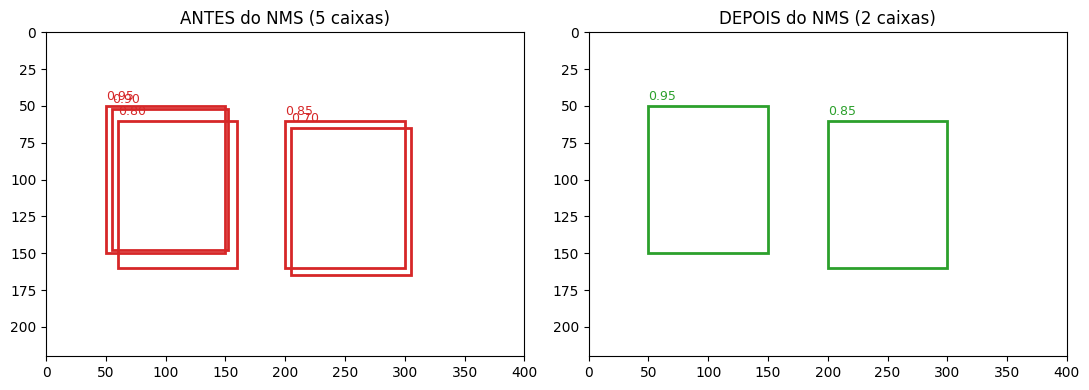

In [4]:
# Conjunto-brinquedo: 5 caixas sobrepostas em torno do mesmo objeto
caixas = np.array([
    [50, 50, 150, 150],   # caixa A
    [55, 52, 152, 148],   # quase identica a A
    [60, 60, 160, 160],   # bem sobreposta a A
    [200, 60, 300, 160],  # outro objeto, sem sobreposicao
    [205, 65, 305, 165],  # quase identica a anterior
], dtype=float)
scores = np.array([0.95, 0.90, 0.80, 0.85, 0.70])

idx_nossos = nms(caixas, scores, limiar_iou=0.5)
idx_tv = nms_tv(torch.tensor(caixas), torch.tensor(scores), 0.5).numpy()
print("NMS (nosso)      :", idx_nossos)
print("NMS (torchvision):", idx_tv)
assert sorted(idx_nossos.tolist()) == sorted(idx_tv.tolist()), "indices divergiram"

def desenhar(ax, caixas, scores, cor, titulo):
    ax.set_xlim(0, 400); ax.set_ylim(0, 220); ax.invert_yaxis()
    ax.set_title(titulo)
    for (x1, y1, x2, y2), s in zip(caixas, scores):
        ret = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor=cor, facecolor='none')
        ax.add_patch(ret)
        ax.text(x1, y1 - 4, f"{s:.2f}", color=cor, fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
desenhar(axes[0], caixas, scores, 'tab:red', f"ANTES do NMS ({len(caixas)} caixas)")
desenhar(axes[1], caixas[idx_nossos], scores[idx_nossos], 'tab:green',
         f"DEPOIS do NMS ({len(idx_nossos)} caixas)")
plt.tight_layout(); plt.show()


## 3. TP, FP e FN

Para avaliar detecções, comparamos cada predição (caixa + classe + score)
com o *ground-truth* (GT) da imagem:

- **TP (verdadeiro positivo):** a predição **casa** com uma GT da mesma
  classe, com IoU acima do limiar (ex.: 0.5).
- **FP (falso positivo):** a predição **não casa** com nenhuma GT livre.
- **FN (falso negativo):** uma GT **não foi prevista** por ninguém.

A regra clássica é: para cada classe, percorrer as predições em ordem
**decrescente de score** e, para cada uma, casar com a melhor GT **ainda
livre** (de mesma classe e IoU ≥ limiar).


In [5]:
def classificar_deteccoes(preds, gts, limiar_iou=0.5):
    """Classifica as predicoes de UMA imagem em TP/FP e conta FN.

    preds: lista de dicts {'caixa': [x1,y1,x2,y2], 'classe': int, 'score': float}
    gts:   lista de dicts {'caixa': [x1,y1,x2,y2], 'classe': int}

    Devolve (tags, fn) onde tags e uma lista 'TP' ou 'FP' (mesma ordem das
    predicoes apos ordenacao por score) e fn e o numero de GTs nao casadas.
    """
    preds_ord = sorted(preds, key=lambda p: -p['score'])
    usados = [False] * len(gts)
    tags = []
    for p in preds_ord:
        melhor_iou, melhor_j = 0.0, -1
        for j, g in enumerate(gts):
            if usados[j] or g['classe'] != p['classe']:
                continue
            v = iou(p['caixa'], g['caixa'])
            if v > melhor_iou:
                melhor_iou, melhor_j = v, j
        if melhor_j >= 0 and melhor_iou >= limiar_iou:
            usados[melhor_j] = True
            tags.append('TP')
        else:
            tags.append('FP')
    fn = sum(1 for u in usados if not u)
    return tags, fn

# Exemplo pequeno
gts = [
    {'caixa': [10, 10, 60, 60], 'classe': 1},
    {'caixa': [80, 20, 130, 70], 'classe': 1},
    {'caixa': [200, 100, 260, 160], 'classe': 2},
]
preds = [
    {'caixa': [12, 11, 62, 61], 'classe': 1, 'score': 0.95},  # TP
    {'caixa': [82, 22, 132, 72], 'classe': 1, 'score': 0.90}, # TP
    {'caixa': [12, 11, 62, 61], 'classe': 1, 'score': 0.80},  # FP (GT ja usada)
    {'caixa': [300, 200, 350, 250], 'classe': 2, 'score': 0.70},  # FP
]
tags, fn = classificar_deteccoes(preds, gts, limiar_iou=0.5)
print('predicoes (apos ordenar por score):', tags)
print('FN:', fn)


predicoes (apos ordenar por score): ['TP', 'TP', 'FP', 'FP']
FN: 1


## 4. Curva PR, AP e mAP

Agora generalizamos para um **conjunto inteiro** de imagens:

1. Para cada classe, junte **todas** as detecções (de todas as imagens) e
   ordene por score decrescente.
2. Caminhe pela lista classificando cada detecção em TP ou FP (casando com a
   melhor GT livre da mesma imagem e classe, IoU ≥ limiar).
3. Acumule TP e FP e calcule:
   $$P = \frac{TP}{TP+FP}, \quad R = \frac{TP}{\text{total de GTs}}.$$
4. O **AP** é a área sob a curva PR. A versão **COCO** interpola a precisão
   máxima em **101 pontos** de revocação igualmente espaçados em $[0, 1]$.
5. O **mAP** é a média do AP entre as classes. O **mAP@\[0.5:0.95\]** repete
   o cálculo para 10 limiares de IoU (0.50, 0.55, …, 0.95) e tira a média.


In [6]:
rng = np.random.default_rng(7)

def caixa_aleatoria(W=320, H=240, lado=(40, 90)):
    w = rng.integers(*lado); h = rng.integers(*lado)
    x1 = rng.integers(0, W - w); y1 = rng.integers(0, H - h)
    return [int(x1), int(y1), int(x1 + w), int(y1 + h)]

def perturbar(c, sigma=8):
    return [int(c[0] + rng.normal(0, sigma)),
            int(c[1] + rng.normal(0, sigma)),
            int(c[2] + rng.normal(0, sigma)),
            int(c[3] + rng.normal(0, sigma))]

NUM_IMAGENS = 5
CLASSES = [1, 2, 3]  # 1=quadrado, 2=circulo, 3=triangulo

gts_imgs, preds_imgs = [], []
for _ in range(NUM_IMAGENS):
    n_gt = rng.integers(2, 4)
    gts_img = [{'caixa': caixa_aleatoria(), 'classe': int(rng.choice(CLASSES))}
               for _ in range(n_gt)]
    preds_img = []
    # detecoes 'boas' a partir das GTs (com score alto)
    for g in gts_img:
        if rng.random() < 0.85:  # 85% de chance de detectar
            preds_img.append({
                'caixa': perturbar(g['caixa'], sigma=6),
                'classe': g['classe'],
                'score': float(rng.uniform(0.6, 0.95)),
            })
    # detecoes 'ruins' aleatorias (FPs)
    for _ in range(rng.integers(1, 4)):
        preds_img.append({
            'caixa': caixa_aleatoria(),
            'classe': int(rng.choice(CLASSES)),
            'score': float(rng.uniform(0.2, 0.7)),
        })
    gts_imgs.append(gts_img)
    preds_imgs.append(preds_img)

print(f"{NUM_IMAGENS} imagens sinteticas; classes={CLASSES}")
for i, (g, p) in enumerate(zip(gts_imgs, preds_imgs)):
    print(f"  img {i}: {len(g)} GT  |  {len(p)} detec")


5 imagens sinteticas; classes=[1, 2, 3]
  img 0: 3 GT  |  6 detec
  img 1: 2 GT  |  3 detec
  img 2: 2 GT  |  5 detec
  img 3: 3 GT  |  4 detec
  img 4: 2 GT  |  5 detec


In [7]:
def _acumular_tp_fp_por_classe(preds_imgs, gts_imgs, classe, limiar_iou):
    """Devolve (scores ordenados, tp acumulado, fp acumulado, total_gt)."""
    itens = []  # (score, eh_tp)
    total_gt = 0
    # para cada imagem, casamos predicoes da classe X com GTs da classe X
    for preds, gts in zip(preds_imgs, gts_imgs):
        gts_c = [g for g in gts if g['classe'] == classe]
        total_gt += len(gts_c)
        preds_c = sorted([p for p in preds if p['classe'] == classe],
                         key=lambda p: -p['score'])
        usados = [False] * len(gts_c)
        for p in preds_c:
            melhor_iou, melhor_j = 0.0, -1
            for j, g in enumerate(gts_c):
                if usados[j]:
                    continue
                v = iou(p['caixa'], g['caixa'])
                if v > melhor_iou:
                    melhor_iou, melhor_j = v, j
            eh_tp = (melhor_j >= 0 and melhor_iou >= limiar_iou)
            if eh_tp:
                usados[melhor_j] = True
            itens.append((p['score'], 1 if eh_tp else 0))
    if total_gt == 0 or not itens:
        return np.array([]), np.array([]), np.array([]), total_gt
    itens.sort(key=lambda x: -x[0])
    scores = np.array([s for s, _ in itens])
    tp = np.array([t for _, t in itens])
    fp = 1 - tp
    return scores, np.cumsum(tp), np.cumsum(fp), total_gt

def precisao_revocacao_ap(preds_imgs, gts_imgs, classe, limiar_iou=0.5):
    """AP estilo COCO (interpolacao em 101 pontos)."""
    scores, tp, fp, total_gt = _acumular_tp_fp_por_classe(
        preds_imgs, gts_imgs, classe, limiar_iou)
    if total_gt == 0 or scores.size == 0:
        return np.array([]), np.array([]), 0.0
    precisao = tp / np.maximum(tp + fp, 1e-12)
    revocacao = tp / total_gt
    # interpolacao em 101 pontos (COCO)
    r_eixo = np.linspace(0, 1, 101)
    # precisao monotona decrescente apos cada ponto
    p_interp = np.maximum.accumulate(precisao[::-1])[::-1]
    ap = 0.0
    for r in r_eixo:
        candidatos = p_interp[revocacao >= r]
        ap += candidatos.max() if candidatos.size > 0 else 0.0
    ap /= 101.0
    return precisao, revocacao, float(ap)

def mAP(preds_imgs, gts_imgs, limiar_iou=0.5):
    aps = []
    for c in CLASSES:
        _, _, ap = precisao_revocacao_ap(preds_imgs, gts_imgs, c, limiar_iou)
        aps.append(ap)
    return float(np.mean(aps)), aps

map50, aps50 = mAP(preds_imgs, gts_imgs, 0.5)
print(f"mAP@0.5 = {map50:.4f}   (AP por classe: {[round(a,4) for a in aps50]})")

limiares = np.arange(0.5, 1.0, 0.05)
maps = [mAP(preds_imgs, gts_imgs, t)[0] for t in limiares]
print(f"mAP@[0.5:0.95] = {np.mean(maps):.4f}")


mAP@0.5 = 0.8350   (AP por classe: [0.505, 1.0, 1.0])
mAP@[0.5:0.95] = 0.4036


## 5. Conferindo com `torchmetrics`

A biblioteca `torchmetrics` traz `MeanAveragePrecision` com a mesma
convenção COCO. Vamos alimentar **os mesmos dados** no formato esperado
e comparar `map_50` e `map` (que é o `mAP@[0.5:0.95]`).


In [8]:
from torchmetrics.detection import MeanAveragePrecision

def para_torchmetrics(preds_imgs, gts_imgs):
    preds_tm, alvos_tm = [], []
    for preds, gts in zip(preds_imgs, gts_imgs):
        preds_tm.append({
            'boxes':  torch.tensor([p['caixa']  for p in preds], dtype=torch.float32).reshape(-1, 4),
            'scores': torch.tensor([p['score']  for p in preds], dtype=torch.float32),
            'labels': torch.tensor([p['classe'] for p in preds], dtype=torch.long),
        })
        alvos_tm.append({
            'boxes':  torch.tensor([g['caixa']  for g in gts],   dtype=torch.float32).reshape(-1, 4),
            'labels': torch.tensor([g['classe'] for g in gts],   dtype=torch.long),
        })
    return preds_tm, alvos_tm

preds_tm, alvos_tm = para_torchmetrics(preds_imgs, gts_imgs)

metrica = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
metrica.update(preds_tm, alvos_tm)
res = metrica.compute()

print(f"torchmetrics  map_50 = {float(res['map_50']):.4f}")
print(f"nossa impl    mAP@0.5= {map50:.4f}")
print(f"torchmetrics  map    = {float(res['map']):.4f}   (mAP@[0.5:0.95])")
print(f"nossa impl           = {np.mean(maps):.4f}")


torchmetrics  map_50 = 0.8350
nossa impl    mAP@0.5= 0.8350
torchmetrics  map    = 0.4036   (mAP@[0.5:0.95])
nossa impl           = 0.4036


## 6. Inferência com YOLO (`ultralytics`)

A família **YOLO** (You Only Look Once) é hoje o padrão de fato para
detecção em produção. Vamos usar o **YOLOv8 nano** (`yolov8n.pt`), o menor
e mais rápido, ótimo para demonstração.

- Em uma única passada pela imagem ele devolve já **caixas + classes + scores**.
- Treinado em COCO (80 classes: pessoa, carro, ônibus, cachorro, etc.).
- Na primeira execução, baixa os pesos (~6 MB) — precisa de internet.


Baixei exemplo.jpg de https://ultralytics.com/images/bus.jpg


Encontradas 6 deteccoes (conf>=0.25):
  classe= 5 (bus         ) conf=0.87  xyxy=[22.899999618530273, 231.3000030517578, 805.0, 756.7999877929688]
  classe= 0 (person      ) conf=0.87  xyxy=[48.599998474121094, 398.6000061035156, 245.3000030517578, 902.7000122070312]
  classe= 0 (person      ) conf=0.85  xyxy=[669.5, 392.20001220703125, 809.7000122070312, 877.0]
  classe= 0 (person      ) conf=0.83  xyxy=[221.5, 405.79998779296875, 345.0, 857.5]
  classe= 0 (person      ) conf=0.26  xyxy=[0.0, 550.5, 63.0, 873.4000244140625]
  classe=11 (stop sign   ) conf=0.26  xyxy=[0.10000000149011612, 254.5, 32.599998474121094, 324.8999938964844]


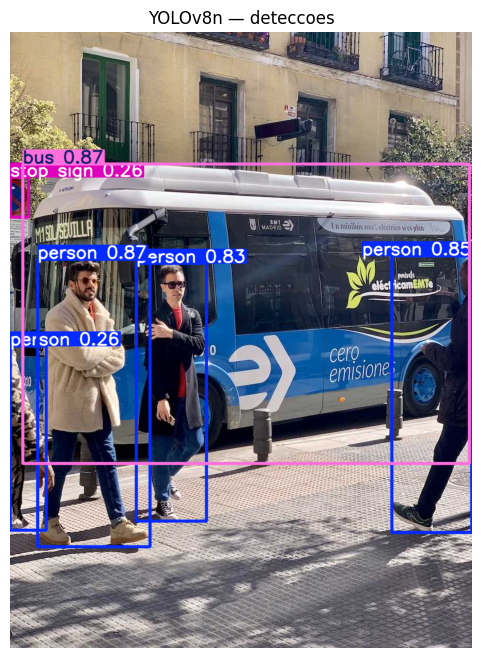

In [9]:
from pathlib import Path
import urllib.request
from ultralytics import YOLO

modelo = YOLO('yolov8n.pt')

# Fonte: usa exemplo.jpg local se existir, senao baixa bus.jpg dos exemplos
fonte_local = Path('exemplo.jpg')
if not fonte_local.exists():
    url = 'https://ultralytics.com/images/bus.jpg'
    try:
        urllib.request.urlretrieve(url, fonte_local)
        print(f"Baixei {fonte_local} de {url}")
    except Exception as e:
        print(f"Falha ao baixar imagem: {e}")
        print("Coloque um arquivo 'exemplo.jpg' nesta pasta para rodar a demo.")

resultados = modelo.predict(str(fonte_local), conf=0.25, verbose=False)
res0 = resultados[0]
nomes = res0.names

print(f"Encontradas {len(res0.boxes)} deteccoes (conf>=0.25):")
for b in res0.boxes:
    cls = int(b.cls.item())
    conf = float(b.conf.item())
    xyxy = b.xyxy.cpu().numpy().ravel().round(1).tolist()
    print(f"  classe={cls:>2} ({nomes[cls]:<12}) conf={conf:.2f}  xyxy={xyxy}")

img_anotada = res0.plot()[..., ::-1]  # BGR -> RGB
plt.figure(figsize=(7, 8))
plt.imshow(img_anotada); plt.axis('off')
plt.title('YOLOv8n — deteccoes')
plt.show()


## 7. Treinando YOLO em um dataset próprio (formato YAML)

Para treinar com **dados seus**, o YOLO espera:

```
dataset_yolo_exemplo/
  data.yaml
  images/train/*.jpg
  images/val/*.jpg
  labels/train/*.txt   # uma linha por objeto: classe xc yc w h (normalizados)
  labels/val/*.txt
```

E um `data.yaml` apontando para essas pastas, com o número de classes e os
nomes. Vamos **gerar um exemplo mínimo sintético** para visualizar o
formato — sem treinar de fato (o treino fica como comentário no fim).


In [10]:
from pathlib import Path
from PIL import Image, ImageDraw

RAIZ = Path('dataset_yolo_exemplo')
for sub in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    (RAIZ / sub).mkdir(parents=True, exist_ok=True)

W, H = 320, 240
NOMES = ['quadrado', 'circulo']

def desenhar_e_anotar(caminho_img, caminho_lbl, formas):
    img = Image.new('RGB', (W, H), 'white')
    dr = ImageDraw.Draw(img)
    linhas = []
    for forma, (x1, y1, x2, y2), cor in formas:
        if forma == 'quadrado':
            dr.rectangle([x1, y1, x2, y2], outline=cor, width=3)
            cls = 0
        else:
            dr.ellipse([x1, y1, x2, y2], outline=cor, width=3)
            cls = 1
        xc = ((x1 + x2) / 2) / W
        yc = ((y1 + y2) / 2) / H
        bw = (x2 - x1) / W
        bh = (y2 - y1) / H
        linhas.append(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    img.save(caminho_img)
    caminho_lbl.write_text("\n".join(linhas) + "\n")

# 2 imagens de treino + 1 de validacao
desenhar_e_anotar(RAIZ/'images/train/img1.jpg', RAIZ/'labels/train/img1.txt',
                  [('quadrado', (30, 40, 110, 120), 'red'),
                   ('circulo', (180, 80, 270, 170), 'blue')])
desenhar_e_anotar(RAIZ/'images/train/img2.jpg', RAIZ/'labels/train/img2.txt',
                  [('quadrado', (60, 30, 150, 130), 'red')])
desenhar_e_anotar(RAIZ/'images/val/img3.jpg', RAIZ/'labels/val/img3.txt',
                  [('circulo', (50, 60, 140, 150), 'blue'),
                   ('quadrado', (170, 90, 260, 180), 'red')])

yaml_txt = f"""path: {RAIZ.resolve()}
train: images/train
val: images/val
nc: {len(NOMES)}
names: {NOMES}
"""
(RAIZ / 'data.yaml').write_text(yaml_txt)

# Mostra a arvore criada e um label + o yaml
print('Arvore criada:')
for p in sorted(RAIZ.rglob('*')):
    print('  ', p.relative_to(RAIZ.parent))

print('\nConteudo de labels/train/img1.txt:')
print((RAIZ/'labels/train/img1.txt').read_text())

print('Conteudo de data.yaml:')
print((RAIZ/'data.yaml').read_text())

# Para treinar de verdade (NAO execute agora -- demora):
# modelo = YOLO('yolov8n.pt')
# modelo.train(data='dataset_yolo_exemplo/data.yaml', epochs=50, imgsz=640)


Arvore criada:
   dataset_yolo_exemplo/data.yaml
   dataset_yolo_exemplo/images
   dataset_yolo_exemplo/images/train
   dataset_yolo_exemplo/images/train/img1.jpg
   dataset_yolo_exemplo/images/train/img2.jpg
   dataset_yolo_exemplo/images/val
   dataset_yolo_exemplo/images/val/img3.jpg
   dataset_yolo_exemplo/labels
   dataset_yolo_exemplo/labels/train
   dataset_yolo_exemplo/labels/train/img1.txt
   dataset_yolo_exemplo/labels/train/img2.txt
   dataset_yolo_exemplo/labels/val
   dataset_yolo_exemplo/labels/val/img3.txt

Conteudo de labels/train/img1.txt:
0 0.218750 0.333333 0.250000 0.333333
1 0.703125 0.520833 0.281250 0.375000

Conteudo de data.yaml:
path: /Users/rooneycoelho/Library/CloudStorage/OneDrive-FundaçãoSãoPaulo/2026.1/Aprendizagem de Máquina/Aula_Deteccao_2h/notebooks/dataset_yolo_exemplo
train: images/train
val: images/val
nc: 2
names: ['quadrado', 'circulo']



## 8. Exercício


In [11]:
# TODO Exercicio 1: recalcule o mAP usando limiar de IoU=0.75 (mais rigoroso) e descreva a diferenca.


## 18. Focal Loss — combatendo o desbalanceamento de classes

Em detectores de **um estágio** (YOLO, SSD, RetinaNet), a esmagadora maioria
das caixas candidatas é **fundo**. A CrossEntropy padrão acaba "afogada" pelo
sinal dos exemplos fáceis. A **Focal Loss** (Lin et al., 2017) ataca isso
pesando MENOS os exemplos em que o modelo já é confiante:

$$\mathrm{FL}(p_t) = -\alpha_t \, (1 - p_t)^{\gamma} \, \log(p_t)$$

Quando $p_t \to 1$ (exemplo fácil), o fator $(1 - p_t)^{\gamma}$ vai a zero e a
contribuição some. Vamos implementar e visualizar.

In [12]:
# Focal Loss binária (objeto vs fundo)
def focal_loss_bin(logits: torch.Tensor, target: torch.Tensor,
                   gamma: float = 2.0, alpha: float = 0.25) -> torch.Tensor:
    '''Focal Loss binária para detecção (objeto=1 / fundo=0).'''
    p = torch.sigmoid(logits)
    # p_t = p se target=1, (1-p) se target=0
    p_t = torch.where(target == 1, p, 1 - p)
    # alpha_t = alpha para positivos, (1-alpha) para negativos
    alpha_t = torch.where(target == 1,
                           torch.full_like(p, alpha),
                           torch.full_like(p, 1.0 - alpha))
    focal_w = (1.0 - p_t) ** gamma
    log_p_t = torch.log(p_t.clamp(min=1e-7))
    return -(alpha_t * focal_w * log_p_t).mean()


# Compara em cenário desbalanceado (95% fundo, 5% objeto)
torch.manual_seed(0)
N_FUNDO, N_OBJETO = 950, 50
target = torch.cat([torch.zeros(N_FUNDO), torch.ones(N_OBJETO)])
# logits: modelo já é bom no fundo (negativos), mas confuso nos objetos (perto de 0)
logits = torch.cat([
    torch.randn(N_FUNDO) - 3.0,      # fundo: logits muito negativos -> p baixo (acerta)
    torch.randn(N_OBJETO) * 0.5,     # objeto: logits ~0 -> p ~0.5 (indeciso)
])

bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, target).item()
fl  = focal_loss_bin(logits, target, gamma=2.0, alpha=0.25).item()
print(f"BCE                                  = {bce:.4f}")
print(f"Focal Loss (gamma=2.0, alpha=0.25)   = {fl:.4f}")
print(f"\nA FL atribui MENOS peso aos 950 exemplos de fundo fácil")
print(f"e MAIS peso relativo aos 50 exemplos de objeto difícil.")

BCE                                  = 0.1150
Focal Loss (gamma=2.0, alpha=0.25)   = 0.0066

A FL atribui MENOS peso aos 950 exemplos de fundo fácil
e MAIS peso relativo aos 50 exemplos de objeto difícil.


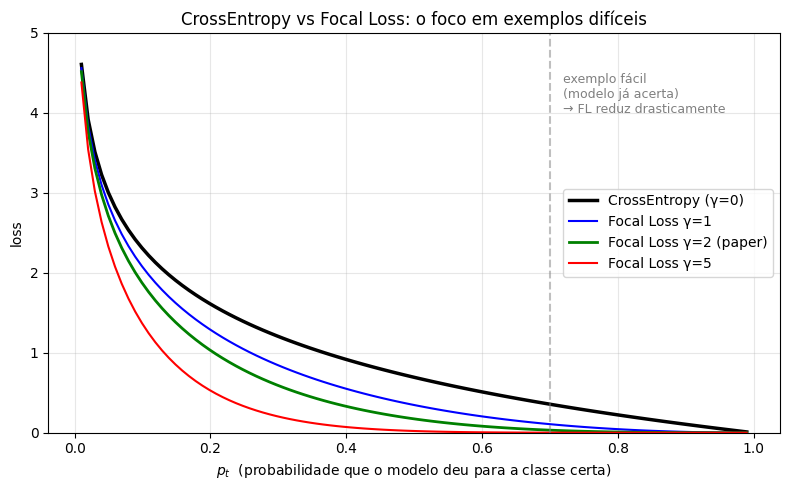

In [13]:
# Visualiza o peso focal vs CE ao longo de p_t
import numpy as np

p = np.linspace(0.01, 0.99, 100)
ce_loss = -np.log(p)
fl_g1 = -np.log(p) * (1 - p) ** 1
fl_g2 = -np.log(p) * (1 - p) ** 2
fl_g5 = -np.log(p) * (1 - p) ** 5

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, ce_loss, "k-", linewidth=2.5, label="CrossEntropy (γ=0)")
ax.plot(p, fl_g1, "b-", label="Focal Loss γ=1")
ax.plot(p, fl_g2, "g-", linewidth=2.0, label="Focal Loss γ=2 (paper)")
ax.plot(p, fl_g5, "r-", label="Focal Loss γ=5")
ax.axvline(0.7, color="gray", linestyle="--", alpha=0.5)
ax.text(0.72, 4.0, "exemplo fácil\n(modelo já acerta)\n→ FL reduz drasticamente",
        fontsize=9, color="gray")
ax.set_xlabel("$p_t$  (probabilidade que o modelo deu para a classe certa)")
ax.set_ylabel("loss")
ax.set_title("CrossEntropy vs Focal Loss: o foco em exemplos difíceis")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 5)
plt.tight_layout(); plt.show()

### Como ler o gráfico

- Para um exemplo **difícil** ($p_t$ pequeno, esquerda do gráfico), todas as
  curvas dão loss alta — atenção é dada.
- Para um exemplo **fácil** ($p_t$ próximo de 1, direita), a CrossEntropy
  ainda contribui; a Focal Loss com γ=2 reduz drasticamente; com γ=5 quase zera.

**O efeito prático:** o gradiente de treinamento foca nos exemplos onde o modelo
ainda erra, em vez de ser dominado pelas dezenas de milhares de exemplos de
fundo já corretos. Foi essa ideia que permitiu o **RetinaNet** (Lin et al.,
2017) alcançar a precisão de detectores de dois estágios mantendo a velocidade
de um estágio.

## Resumo e próximos passos

Neste notebook nós:

- Implementamos **IoU** (escalar e matricial) e **NMS** do zero e batemos
  com o `torchvision.ops.nms`.
- Classificamos detecções em **TP/FP/FN** com o casamento por IoU.
- Calculamos **PR, AP e mAP** (versão COCO 101 pontos) e conferimos com
  `torchmetrics.detection.MeanAveragePrecision`.
- Rodamos **YOLOv8n** com `ultralytics` para inferência.
- Vimos como preparar um **dataset próprio** no formato YAML do YOLO.

No próximo notebook (`04_segmentacao.ipynb`) saímos da detecção e entramos
em **segmentação semântica e de instâncias**: máscaras pixel a pixel,
arquitetura U-Net, e demo com modelos pré-treinados.
